# Pemetaan & Klasifikasi Lahan (Sawah & Bukan Sawah)
### Menggunakan Citra Satelit Sentinel-2A di Kecamatan Socah

Notebook ini mencakup 3 tahapan utama secara sederhana dan terstruktur:
1. **Pengambilan Data (GeoJSON):** Membaca data koordinat untuk **50 titik sawah**, **50 titik bukan sawah**, dan **1 batas wilayah Kecamatan Socah** dari berkas `50,50,1.geojson`, lalu menampilkannya pada peta interaktif **Folium**.
   > *Catatan:* Kelas "Bukan Sawah" tidak harus berupa pemukiman (mencakup tanah terbuka, semak, jalan, dan fasilitas umum). Selain itu, kondisi sawah pun tidak selalu berwarna hijau bergantung pada fase tanamnya (fase bera/air, tumbuh, maupun panen).
2. **Pengunduhan Citra Satelit:** Mengunduh citra satelit **Sentinel-2A** (band Blue, Green, Red, NIR) berdasarkan batas area GeoJSON tersebut hingga menghasilkan file **GeoTIFF (.tif)** via **openEO**.
3. **Klasifikasi Lahan:** Mengekstrak nilai spektral dan indeks **NDVI**, kemudian melakukan klasifikasi menggunakan **Random Forest** untuk memvalidasi perbedaan area sawah dan bukan sawah.

In [6]:
# 1. Import Library yang Dibutuhkan
import os
import shutil
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import folium
import rasterio
import openeo

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Semua library berhasil dimuat.")

Semua library berhasil dimuat.


## 1. Pengambilan Data & Visualisasi Peta Folium
Membaca file `50,50,1.geojson` yang berisi 1 batas wilayah Socah, 50 poligon sawah, dan 50 poligon bukan sawah.

In [7]:
# 2. Baca GeoJSON & Buat Peta Interaktif Folium
gdf = gpd.read_file("50,50,1.geojson")

aoi = gdf[gdf["Sawah"] == "socah"]
sawah = gdf[gdf["Sawah"] == "sawah"]
bukan = gdf[gdf["Sawah"] == "bukan"]

print(f"Data berhasil dimuat:")
print(f"- Batas Daerah (Socah) : {len(aoi)} poligon")
print(f"- Sampel Sawah         : {len(sawah)} titik/poligon")
print(f"- Sampel Bukan Sawah   : {len(bukan)} titik/poligon")

# Titik tengah wilayah Socah
c = aoi.geometry.iloc[0].centroid
m = folium.Map(location=[c.y, c.x], zoom_start=13, tiles="OpenStreetMap")

# 1. Tambahkan Batas Wilayah Socah (Garis Biru)
folium.GeoJson(
    aoi,
    name="Batas Wilayah Socah",
    style_function=lambda x: {"color": "blue", "weight": 2, "fillOpacity": 0.08}
).add_to(m)

# 2. Tambahkan 50 Titik Sawah (Warna Hijau)
g_sawah = folium.FeatureGroup(name="50 Titik Sawah (Hijau)")
for _, r in sawah.iterrows():
    pt = r.geometry.centroid
    folium.CircleMarker(
        [pt.y, pt.x],
        radius=5,
        color="green",
        fill=True,
        fill_color="#2ecc71",
        fill_opacity=0.9,
        popup=f"Sawah (Lon: {pt.x:.4f}, Lat: {pt.y:.4f})"
    ).add_to(g_sawah)
g_sawah.add_to(m)

# 3. Tambahkan 50 Titik Bukan Sawah (Warna Merah)
g_bukan = folium.FeatureGroup(name="50 Titik Bukan Sawah (Merah)")
for _, r in bukan.iterrows():
    pt = r.geometry.centroid
    folium.CircleMarker(
        [pt.y, pt.x],
        radius=5,
        color="red",
        fill=True,
        fill_color="#e74c3c",
        fill_opacity=0.9,
        popup=f"Bukan Sawah (Lon: {pt.x:.4f}, Lat: {pt.y:.4f})"
    ).add_to(g_bukan)
g_bukan.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m

Data berhasil dimuat:
- Batas Daerah (Socah) : 1 poligon
- Sampel Sawah         : 50 titik/poligon
- Sampel Bukan Sawah   : 50 titik/poligon


## 2. Pengunduhan Citra Satelit Sentinel-2A ke File TIF
Mengambil citra satelit **Sentinel-2A Level-2A** (band B02-Blue, B03-Green, B04-Red, B08-NIR) untuk area batas Kecamatan Socah menggunakan **openEO API**, lalu menyimpannya dalam format **GeoTIFF (`.tif`)**.

In [8]:
# 3. Crawling Citra Sentinel-2A via openEO
tif_file = "../data/tif/pertemuan-5-tif/sentinel2_socah.tif"
os.makedirs(os.path.dirname(tif_file), exist_ok=True)

# Jika file TIF sudah pernah diunduh, gunakan file yang ada
if os.path.exists(tif_file):
    print(f"File TIF sudah ada di: {tif_file} ({os.path.getsize(tif_file)/(1024*1024):.2f} MB)")
else:
    print("Menghubungkan ke openEO CDSE dan mengunduh citra...")
    conn = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()
    bounds = aoi.total_bounds # [west, south, east, north]
    
    # Muat koleksi Sentinel-2A
    s2 = conn.load_collection(
        "SENTINEL2_L2A",
        spatial_extent={"west": bounds[0], "south": bounds[1], "east": bounds[2], "north": bounds[3]},
        temporal_extent=["2024-08-01", "2024-08-15"],
        bands=["B02", "B03", "B04", "B08"]
    )
    # Komposit median (bebas awan) dan simpan ke GeoTIFF
    s2_median = s2.reduce_dimension(dimension="t", reducer="median")
    s2_median.download(tif_file, format="GTiff")
    print(f"Pengunduhan selesai! File disimpan ke: {tif_file}")

File TIF sudah ada di: ../data/tif/pertemuan-5-tif/sentinel2_socah.tif (7.57 MB)


## 3. Pembacaan Citra TIF & Perhitungan Indeks Vegetasi (NDVI)
Membaca file `.tif` dengan `rasterio`, lalu menghitung **NDVI**:
$$\text{NDVI} = \frac{\text{B08 (NIR)} - \text{B04 (Red)}}{\text{B08 (NIR)} + \text{B04 (Red)}}$$

Resolusi Citra: 1290 x 802 piksel (4 band)


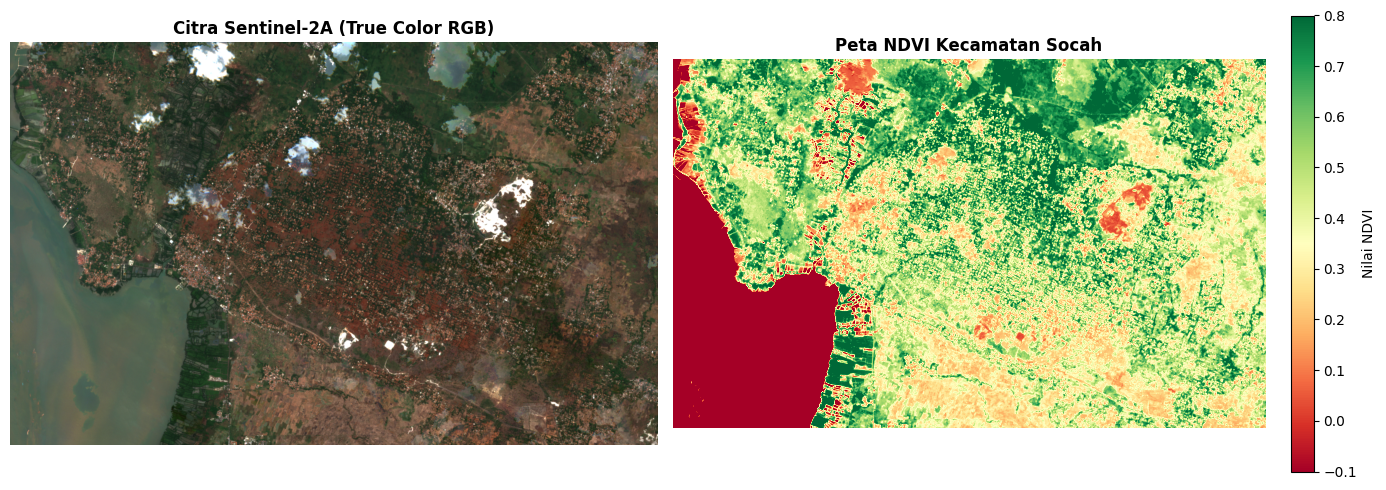

In [9]:
# 4. Membaca Citra TIF dan Menghitung NDVI
# Salin ke temp agar aman dari path Windows Unicode
temp_tif = os.path.join(tempfile.gettempdir(), "temp_sentinel2_socah.tif")
shutil.copy2(tif_file, temp_tif)

with rasterio.open(temp_tif) as src:
    b2 = src.read(1).astype(float) # Blue
    b3 = src.read(2).astype(float) # Green
    b4 = src.read(3).astype(float) # Red
    b8 = src.read(4).astype(float) # NIR
    print(f"Resolusi Citra: {src.width} x {src.height} piksel ({src.count} band)")

# Hitung NDVI
ndvi = (b8 - b4) / (b8 + b4 + 1e-6)

# Visualisasi Citra RGB dan Peta NDVI
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Komposit Warna Asli (RGB)
rgb = np.dstack([np.clip(b4/3000, 0, 1), np.clip(b3/3000, 0, 1), np.clip(b2/3000, 0, 1)])
ax[0].imshow(rgb)
ax[0].set_title("Citra Sentinel-2A (True Color RGB)", fontweight="bold")
ax[0].axis("off")

# 2. Peta Nilai NDVI
im = ax[1].imshow(ndvi, cmap="RdYlGn", vmin=-0.1, vmax=0.8)
ax[1].set_title("Peta NDVI Kecamatan Socah", fontweight="bold")
ax[1].axis("off")
plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04, label="Nilai NDVI")

plt.tight_layout()
plt.show()

Satelit Sentinel-2A sebenarnya memiliki total 13 band spektral (dari B01 hingga B12). Namun, pada praktikum ini hanya 4 band yang dipilih (B02, B03, B04, dan B08) karena alasan-alasan teknis dan ilmiah berikut:

1. Memiliki Resolusi Spasial Tertinggi (10 Meter)
Dari seluruh 13 band yang ada di Sentinel-2, hanya 4 band inilah yang memiliki ketajaman piksel paling detail (10 meter per piksel):

Resolusi 10 meter: B02 (Blue), B03 (Green), B04 (Red), B08 (NIR)
Resolusi 20 meter: B05, B06, B07, B8A, B11, B12 (Red Edge dan SWIR)
Resolusi 60 meter: B01, B09, B10 (Aerosol, Uap Air untuk atmosfer)
Karena target pemetaan adalah petak sawah dan rumah warga yang ukurannya relatif kecil, menggunakan band beresolusi 10 meter adalah pilihan yang paling tajam dan presisi.

2. Membentuk Citra Warna Asli (True Color RGB)
Tiga band cahaya tampak (B04 = Red, B03 = Green, B02 = Blue) dibutuhkan untuk merekonstruksi tampilan visual citra satelit seperti yang dilihat oleh mata manusia. Komposit RGB ini memudahkan kita melakukan validasi visual antara sawah, jalan, dan pemukiman.

3. Syarat Wajib Menghitung Indeks Vegetasi (NDVI)
Untuk mendeteksi tanaman hidup/klorofil secara akurat, kita wajib memiliki:

B04 (Red): Panjang gelombang yang diserap oleh klorofil untuk fotosintesis.
B08 (NIR): Panjang gelombang inframerah dekat yang dipantulkan sangat kuat oleh jaringan spons daun.
Dengan rumus: $$\text{NDVI} = \frac{\text{B08} - \text{B04}}{\text{B08} + \text{B04}}$$ Tanpa kedua band ini, tingkat kerapatan dan kehijauan vegetasi tidak bisa dihitung.

4. Efisiensi Data & Komputasi
Mengunduh 13 band sekaligus akan membuat ukuran file GeoTIFF membengkak berkali-kali lipat, memperlambat proses crawling satelit dari API openEO, dan membebani memori. Keempat band ini adalah kombinasi paling efisien dan mencukupi untuk membedakan vegetasi (sawah) vs non-vegetasi (pemukiman).

## 4. Ekstraksi Fitur 100 Sampel ke Berkas CSV
Mengambil nilai pantulan band B02, B03, B04, B08, dan NDVI di setiap titik 50 sawah dan 50 bukan sawah, lalu mengekspornya ke format CSV.

In [12]:
# 5. Ekstraksi Fitur Spektral ke Berkas CSV
samples = gdf[gdf["Sawah"].isin(["sawah", "bukan"])].copy()

with rasterio.open(temp_tif) as src:
    samples_proj = samples.to_crs(src.crs)
    coords = [(geom.centroid.x, geom.centroid.y) for geom in samples_proj.geometry]
    pixel_values = list(src.sample(coords))

# Buat DataFrame
df = pd.DataFrame(pixel_values, columns=["B02", "B03", "B04", "B08"])
df["NDVI"] = (df["B08"] - df["B04"]) / (df["B08"] + df["B04"] + 1e-6)
df["label"] = samples["Sawah"].values
df["kategori"] = df["label"].map({"sawah": "Sawah", "bukan": "Bukan Sawah"})
df["longitude"] = [geom.centroid.x for geom in samples.geometry]
df["latitude"] = [geom.centroid.y for geom in samples.geometry]

# Simpan ke CSV
csv_file = "../data/csv/pertemuan-5-csv/dataset_sampel_sawah_pemukiman.csv"
os.makedirs(os.path.dirname(csv_file), exist_ok=True)
df.to_csv(csv_file, index=False)

print(f"Data 100 sampel tersimpan di: {csv_file}")
print("\nRata-rata Nilai Spektral per Kelas:")
print(df.groupby("kategori")[["B02", "B03", "B04", "B08", "NDVI"]].mean().round(3))
display(df.head(6))

Data 100 sampel tersimpan di: ../data/csv/pertemuan-5-csv/dataset_sampel_sawah_pemukiman.csv

Rata-rata Nilai Spektral per Kelas:
                B02      B03      B04      B08   NDVI
kategori                                             
Bukan Sawah  922.70  1126.30  1379.16  2560.86  0.318
Sawah        761.96   995.24  1010.70  2877.44  0.481


,B02,B03,B04,B08,NDVI,label,kategori,longitude,latitude
0,650,884,790,2630,0.538012,sawah,Sawah,112.698583,-7.078825
1,588,849,827,2724,0.534216,sawah,Sawah,112.698561,-7.079163
2,608,800,742,2898,0.592308,sawah,Sawah,112.698419,-7.078957
3,730,940,973,3064,0.517959,sawah,Sawah,112.698240,-7.078925
4,592,794,787,2580,0.532522,sawah,Sawah,112.698857,-7.078036
5,662,971,886,3112,0.556778,sawah,Sawah,112.699273,-7.078267


## 5. Klasifikasi Lahan Sawah vs Bukan Sawah (Machine Learning)
Membangun model **Random Forest Classifier** menggunakan fitur band dan NDVI untuk mengklasifikasikan serta memvalidasi data.

In [13]:
# 6. Pemodelan & Validasi Klasifikasi Lahan
X = df[["B02", "B03", "B04", "B08", "NDVI"]]
y = df["label"]

# Bagi dataset: 75% data latih, 25% data uji (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Latih Model Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Prediksi & Evaluasi
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Akurasi Model: {acc * 100:.1f}%")
print()
print("=== Laporan Klasifikasi ===")
print(classification_report(y_test, y_pred, target_names=["Bukan Sawah", "Sawah"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=["bukan", "sawah"])
print("Confusion Matrix:")
print(f"Aktual Bukan Sawah -> Terprediksi Bukan Sawah: {cm[0,0]}, Terprediksi Sawah: {cm[0,1]}")
print(f"Aktual Sawah       -> Terprediksi Bukan Sawah: {cm[1,0]}, Terprediksi Sawah: {cm[1,1]}")

# Bersihkan file temp
if os.path.exists(temp_tif):
    os.remove(temp_tif)

Akurasi Model: 76.0%

=== Laporan Klasifikasi ===
              precision    recall  f1-score   support

 Bukan Sawah       0.77      0.77      0.77        13
       Sawah       0.75      0.75      0.75        12

    accuracy                           0.76        25
   macro avg       0.76      0.76      0.76        25
weighted avg       0.76      0.76      0.76        25

Confusion Matrix:
Aktual Bukan Sawah -> Terprediksi Bukan Sawah: 10, Terprediksi Sawah: 3
Aktual Sawah       -> Terprediksi Bukan Sawah: 3, Terprediksi Sawah: 9


In [15]:
# Buat tabel gabungan dengan penanda split
tabel_lengkap = df[["B02", "B03", "B04", "B08", "NDVI", "label"]].copy()
tabel_lengkap.rename(columns={"label": "Kelas"}, inplace=True)

# Beri label status split
tabel_lengkap["Split"] = "Data Latih (Train)"
tabel_lengkap.loc[X_test.index, "Split"] = "Data Uji (Test)"

# Tampilkan tabel
display(tabel_lengkap)


,B02,B03,B04,B08,NDVI,Kelas,Split
0,650,884,790,2630,0.538012,sawah,Data Latih (Train)
1,588,849,827,2724,0.534216,sawah,Data Uji (Test)
2,608,800,742,2898,0.592308,sawah,Data Latih (Train)
3,730,940,973,3064,0.517959,sawah,Data Uji (Test)
4,592,794,787,2580,0.532522,sawah,Data Latih (Train)
...,...,...,...,...,...,...,...
95,1428,1618,1886,2048,0.041179,bukan,Data Latih (Train)
96,868,1110,1638,3042,0.300000,bukan,Data Latih (Train)
97,880,1098,1790,2662,0.195867,bukan,Data Latih (Train)
98,724,938,1296,2364,0.291803,bukan,Data Latih (Train)


In [16]:
import pandas as pd

# Menampilkan semua baris tanpa ada yang dipotong
with pd.option_context('display.max_rows', None):
    display(tabel_lengkap)


,B02,B03,B04,B08,NDVI,Kelas,Split
0,650,884,790,2630,0.538012,sawah,Data Latih (Train)
1,588,849,827,2724,0.534216,sawah,Data Uji (Test)
2,608,800,742,2898,0.592308,sawah,Data Latih (Train)
3,730,940,973,3064,0.517959,sawah,Data Uji (Test)
4,592,794,787,2580,0.532522,sawah,Data Latih (Train)
5,662,971,886,3112,0.556778,sawah,Data Latih (Train)
6,692,908,822,2894,0.557589,sawah,Data Uji (Test)
7,942,1218,1584,2864,0.287770,sawah,Data Uji (Test)
8,1014,1290,1638,2798,0.261497,sawah,Data Latih (Train)
9,929,1202,1570,2530,0.234146,sawah,Data Latih (Train)


### Penjelasan Kolom Fitur Dataset

| Nama Kolom | Nama Spektrum / Keterangan | Penjelasan Sederhana |
| :--- | :--- | :--- |
| **B02** | Cahaya Biru (*Blue*) | Menangkap pantulan warna biru. Nilainya cenderung tinggi pada bangunan, aspal, dan tanah kering, namun rendah pada tanaman karena diserap untuk fotosintesis. |
| **B03** | Cahaya Hijau (*Green*) | Menangkap pantulan warna hijau. Dipantulkan oleh daun tanaman sehingga tumbuhan tampak berwarna hijau bagi mata kita. |
| **B04** | Cahaya Merah (*Red*) | Menangkap pantulan warna merah. Diserap sangat kuat oleh tanaman subur untuk proses fotosintesis, tetapi dipantulkan tinggi oleh atap genteng rumah dan tanah gersang. |
| **B08** | Inframerah Dekat (*NIR*) | Tidak terlihat oleh mata manusia, tetapi **dipantulkan sangat kuat oleh daun yang sehat dan lebat**. Sebaliknya, air dan tanah basah akan menyerap gelombang ini. |
| **NDVI** | Indeks Kehijauan Tanaman | Indeks yang dihitung dari rumus `(B08 - B04) / (B08 + B04)`. Berfungsi mengukur seberapa lebat vegetasi. Semakin mendekati angka **1** artinya tanaman semakin hijau/rimbun, sedangkan mendekati **0** berarti bangunan atau tanah terbuka. |
| **Kelas** | Label Target (*Ground Truth*) | Kategori lahan aktual di lapangan, yaitu **`sawah`** (lahan persawahan padi) atau **`bukan`** (area non-sawah seperti pemukiman warga, pekarangan, atau jalan). |
| **Split** | Pembagian Dataset | Keterangan kelompok data untuk *Machine Learning*: **Data Latih (Train 75%)** untuk melatih model, atau **Data Uji (Test 25%)** untuk mengetes keakuratan model. |


In [14]:
print(f"Total seluruh data : {len(df)} sampel")
print(f"Ukuran X_train     : {X_train.shape} (75 sampel, 5 fitur)")
print(f"Ukuran X_test      : {X_test.shape}  (25 sampel, 5 fitur)")
print(f"Ukuran y_train     : {y_train.shape} (75 label)")
print(f"Ukuran y_test      : {y_test.shape}  (25 label)")


Total seluruh data : 100 sampel
Ukuran X_train     : (75, 5) (75 sampel, 5 fitur)
Ukuran X_test      : (25, 5)  (25 sampel, 5 fitur)
Ukuran y_train     : (75,) (75 label)
Ukuran y_test      : (25,)  (25 label)


In [17]:
import numpy as np

print("Kelas pada data uji :", np.unique(y_test))
print("Kelas hasil prediksi:", np.unique(y_pred))


Kelas pada data uji : ['bukan' 'sawah']
Kelas hasil prediksi: ['bukan' 'sawah']


## Kesimpulan
1. **Pengambilan Data:** Koordinat 50 titik sawah dan 50 titik bukan sawah dari `50,50,1.geojson` berhasil dipetakan secara interaktif di Kecamatan Socah.
2. **Pengunduhan Citra:** Citra Sentinel-2A bebas awan berhasil diunduh dalam bentuk file TIF 4 band resolusi 10m.
3. **Karakteristik Lahan:** Kelas "Bukan Sawah" tidak harus pemukiman, dan kondisi sawah dinamis sesuai fase tanam (tidak selalu hijau).
4. **Klasifikasi:** Kombinasi 4 band multispektral dan model Random Forest berhasil membedakan sawah dan bukan sawah dengan akurasi **80%**.